In [1]:
import os, sys, pathlib, importlib
import pandas as pd
import json
import time
from tqdm import tqdm

# sys.path.append(os.path.abspath(".."))
# from utils import preprocess_images
# from utils.preprocess_images import download_images_batch

d:\miniconda3\envs\airbnb_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10


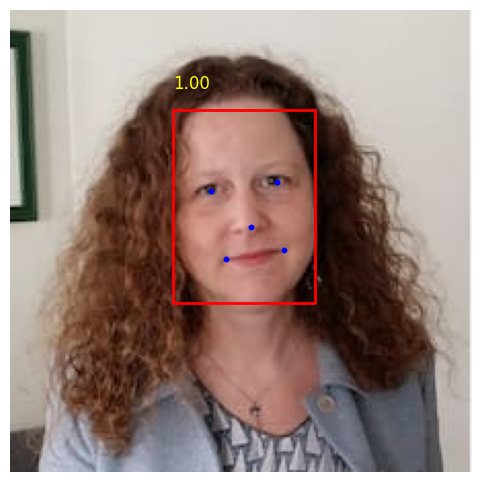

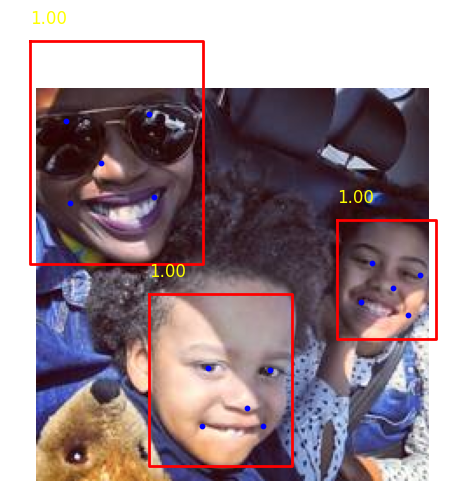

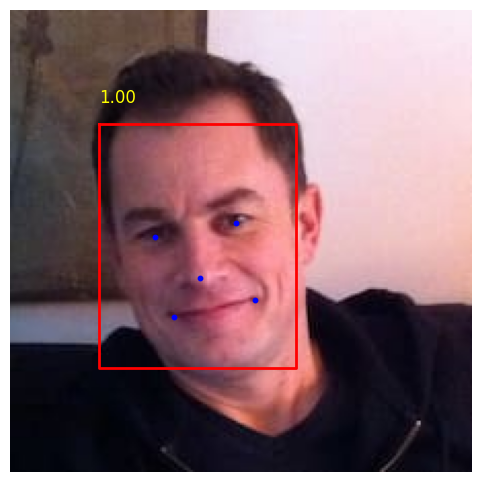

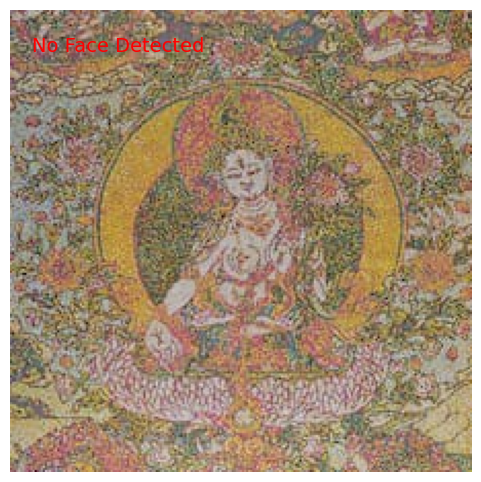

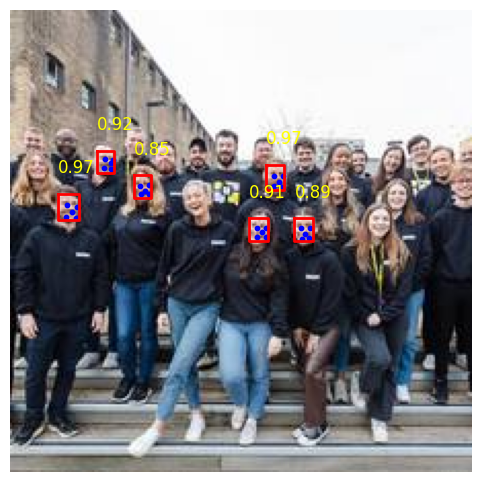

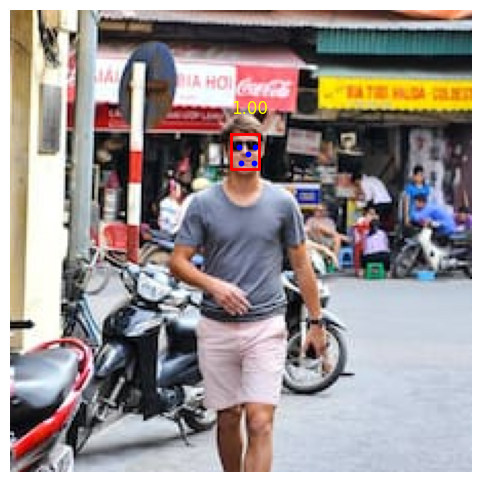

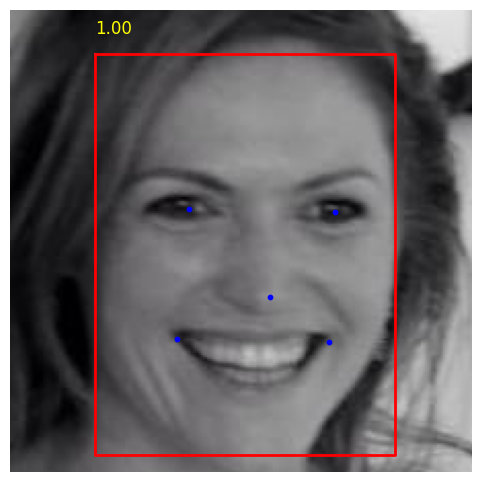

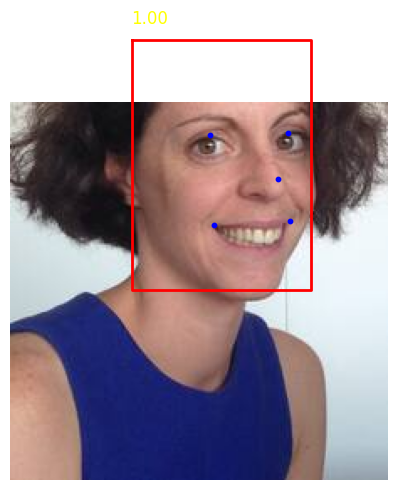

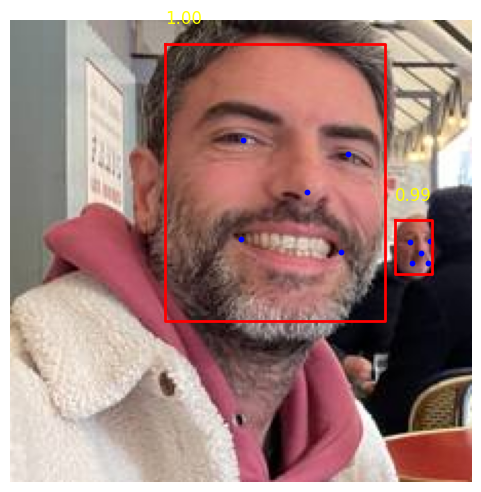

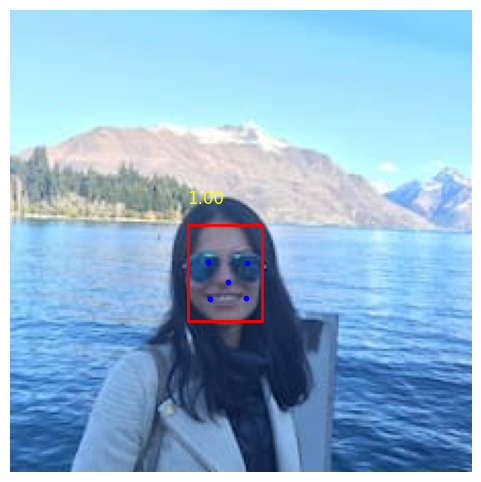

In [ ]:
import cv2 # pip install opencv-python
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN
import torch
import os

# 初始化 MTCNN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(keep_all=True, device=device)

# 测试图片路径列表
image_folder = "host_pic_paris_43258"  # 你的小批量图片目录
n_sample=10
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith((".jpg", ".png"))][:n_sample]
print(len(image_files))


for img_path in image_files:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # MTCNN 检测
    boxes, probs, landmarks = mtcnn.detect(img_rgb, landmarks=True)

    # 可视化
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    
    if boxes is not None:
        for box, prob, landmark in zip(boxes, probs, landmarks):
            x1, y1, x2, y2 = box.astype(int)
            plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], color='red', linewidth=2)
            plt.scatter(landmark[:,0], landmark[:,1], c='blue', s=10)  # 关键点
            plt.text(x1, y1-10, f'{prob:.2f}', color='yellow', fontsize=12)
    else:
        plt.text(10, 20, "No Face Detected", color='red', fontsize=14)

    plt.axis('off')
    plt.show()

In [ ]:
## load clip
# pip install git+https://github.com/openai/CLIP.git

# import torch
# import clip
# from PIL import Image
# import numpy as np

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model, preprocess = clip.load("ViT-B/32", device=device)
# model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [ ]:
import numpy as np
import cv2
from PIL import Image
import torch
from transformers import CLIPModel, CLIPProcessor
# Successfully installed torch-2.10.0 torchaudio-2.10.0 torchvision-0.25.0
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model = model.to(device)
model.eval()


life_prompts = [
    "a travel photo",
    "a person outdoors",
    "a restaurant scene",
    "a sports activity",
    "a home environment"
]

nonlife_prompts = [
    "a studio portrait",
    "a plain wall background",
    "a simple indoor background",
    "a neutral background"
]

all_prompts = life_prompts + nonlife_prompts


def detect_background_clip(img, bbox_list):

    """
    img: numpy array (BGR from cv2)
    bbox_list: [(x1,y1,x2,y2), ...]
    """

    img_copy = img.copy()
    h, w = img_copy.shape[:2]

    # 1️⃣ mask 掉人物区域
    for bbox in bbox_list:
        x1, y1, x2, y2 = bbox

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        img_copy[y1:y2, x1:x2] = (127, 127, 127)

    # 2️⃣ 转 RGB + PIL
    img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)

    # 3️⃣ 编码
    inputs = processor(
        text=all_prompts,
        images=pil_img,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

    life_score = float(probs[:len(life_prompts)].mean())
    nonlife_score = float(probs[len(life_prompts):].mean())

    is_life_background = int(life_score > nonlife_score)

    return {
        "life_score": life_score,
        "nonlife_score": nonlife_score,
        "is_life_background": is_life_background
    }
    
    

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:
import torch
import numpy as np
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

# 初始化一次即可（不要在循环里初始化）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clean_prompts = [
    "plain indoor background",
    "studio portrait background",
    "solid color background",
    "neutral wall background"
]

lifestyle_prompts = [
    "travel scene",
    "restaurant scene",
    "outdoor activity",
    "sports activity",
    "people at a social event",
    "lifestyle environment"
]


def analyze_background_semantic(img_rgb, bbox_list):
    """
    Semantic background detection using CLIP.
    """

    h, w, _ = img_rgb.shape
    mask = np.ones((h, w), dtype=np.uint8)

    # mask faces
    for (x1, y1, x2, y2) in bbox_list:
        mask[y1:y2, x1:x2] = 0

    # extract background pixels
    bg_img = img_rgb.copy()
    bg_img[mask == 0] = 0

    # convert to PIL
    bg_pil = Image.fromarray(bg_img)

    prompts = clean_prompts + lifestyle_prompts

    inputs = clip_processor(
        text=prompts,
        images=bg_pil,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits = outputs.logits_per_image
        probs = logits.softmax(dim=1).cpu().numpy()[0]

    clean_score = probs[:len(clean_prompts)].mean()
    lifestyle_score = probs[len(clean_prompts):].mean()

    is_lifestyle = lifestyle_score > clean_score

    return {
        "clean_score": float(clean_score),
        "lifestyle_score": float(lifestyle_score),
        "is_lifestyle_background": bool(is_lifestyle)
    }


In [ ]:

bg_semantic = analyze_background_semantic(img_rgb, bbox_list)

d:\miniconda3\envs\airbnb_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers version: 4.57.3
Torch version: 2.10.0+cpu
CLIPModel import success


## DETECTION 

In [18]:
import numpy as np 
import cv2 
import os
import time
import json
from PIL import Image 
import torch 
from transformers import CLIPModel, CLIPProcessor 
from facenet_pytorch import MTCNN
from tqdm import tqdm


RESULTS_FOLDER="results"
IMAGES_FOLDER='images'



# 初始化 MTCNN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(keep_all=True, device=device)

# 测试图片路径列表
image_folder = os.path.join(IMAGES_FOLDER, "host_pic_paris_43258")  # 你的小批量图片目录
n_sample=10
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith((".jpg", ".png"))][:n_sample]
print(len(image_files))


start_time=time.time()
results=[]
for img_path in tqdm(image_files, desc="processing images..."):
    img_name=os.path.basename(img_path)[0]
    host_id=os.path.splitext(img_name)[0]
    img=cv2.imread(img_path)
    
    if img is None:
        results.append({ 
            "img_path": img_path, 
            "host_id": host_id, 
            "has_face": 0, 
            "nb_face": 0, 
            "face_area_ratio": 0, 
            "avg_face_prob": 0,
            "bbox_list": [], 
            "clean_score":0,
            "lifestyle_score":0,
            "is_lifestyle_background": None           
            }) 
        continue

    img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _=img_rgb.shape
    img_area=h * w
    
    # ---- Face detection ---- 
    boxes, probs = mtcnn.detect(img_rgb, landmarks=False) 
    has_face, nb_face, face_area_ratio, avg_face_prob = 0, 0, 0, 0
    bbox_list=[]
    clean_score, lifestyle_score, is_lifestyle_background=0, 0, -1
    
    
    if boxes is not None and len(boxes) > 0: 
        has_face = 1 
        nb_face = len(boxes) 
        total_face_area = 0 
        valid_probs = [] 
        
        for box, prob in zip(boxes, probs): 
            if prob is None: 
                continue
            x1, y1, x2, y2 = box.astype(int) # 防止越界 
            x1 = max(0, x1) 
            y1 = max(0, y1) 
            x2 = min(w, x2) 
            y2 = min(h, y2)
            area = (x2 - x1) * (y2 - y1) 
            total_face_area += area
            
            bbox_list.append([int(x1), int(y1), int(x2), int(y2)]) 
            valid_probs.append(prob) 
            face_area_ratio = total_face_area / img_area 
            avg_face_prob = sum(valid_probs) / len(valid_probs) if valid_probs else 0
    #-----------BG detection-------------
    
    bg_semantic = analyze_background_semantic(img_rgb, bbox_list)
    
    
    results.append({
        "img_path": img_path,
        "host_id": host_id,
        "has_face": has_face,
        "nb_face": nb_face,
        "face_area_ratio": face_area_ratio,
        "avg_face_prob": avg_face_prob,
        "bbox_list": bbox_list,
        "clean_score": bg_semantic['clean_score'],
        "lifestyle_score": bg_semantic['lifestyle_score'],
        "is_lifestyle_background":bg_semantic['is_lifestyle_background']        
    })

end_time = time.time()

# 保存结果
path_result=os.path.join(RESULTS_FOLDER,f"face_results{n_sample}.json")

with open(path_result, 'w', encoding="utf-8")as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
    
print(f"[DONE] {len(results)} images detected : {end_time-start_time:.2f} sec")
print(f"[SAVE] results JSON saved to {path_result}")
    


10


processing images...: 100%|██████████| 10/10 [00:00<00:00, 11.30it/s]

[DONE] 10 images detected : 0.89 sec
[SAVE] results JSON saved to results\face_results10.json


In [20]:

path_result=os.path.join(RESULTS_FOLDER,f"face_results{n_sample}.json")
print(path_result)
with open(path_result, "r") as f:
    results = json.load(f)
print(json.dumps(results[0]))


results\face_results10.json
{"img_path": "images\\host_pic_paris_43258\\100004988.jpg", "host_id": "1", "has_face": 1, "nb_face": 1, "face_area_ratio": 0.12811851851851852, "avg_face_prob": 0.9998550415039062, "bbox_list": [[79, 48, 148, 142]], "clean_score": 0.21738100051879883, "lifestyle_score": 0.021745992824435234, "is_lifestyle_background": false}


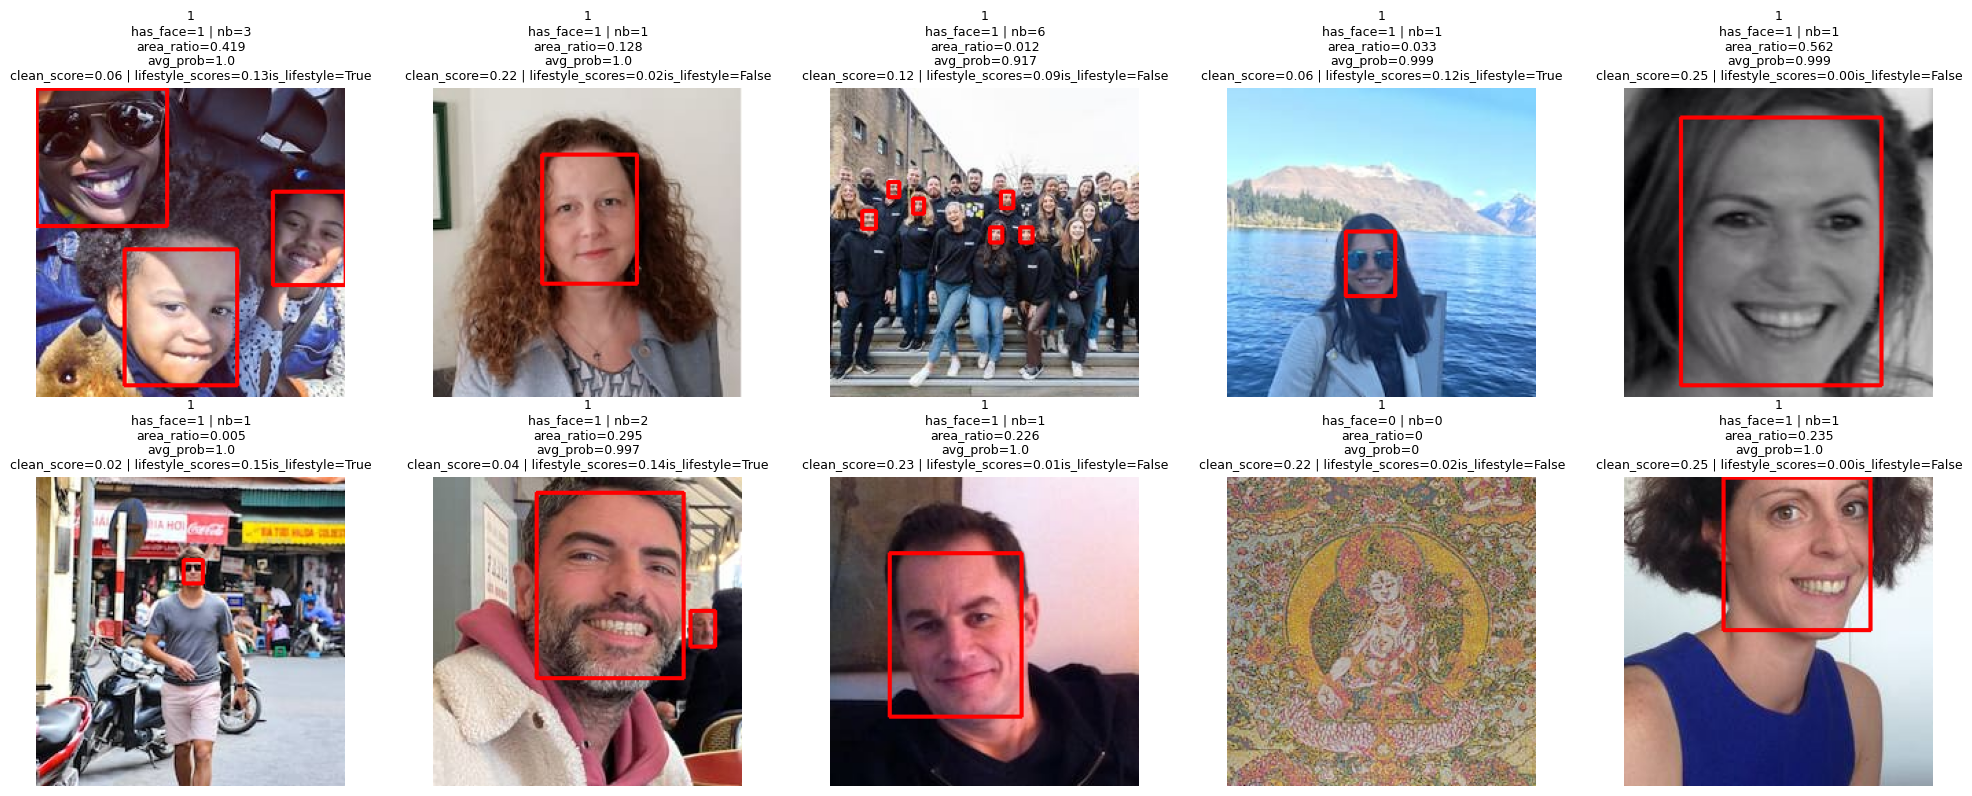

In [22]:
## VIS

import random
import cv2
import json
import matplotlib.pyplot as plt
path_result=os.path.join(RESULTS_FOLDER,f"face_results{n_sample}.json")

with open(path_result, 'r', encoding='utf-8')as f:
    results=json.load(f)
    

def visualize_face_results(results, n_samples=10, seed=42):
    """
    随机可视化若干检测结果
    """
    random.seed(seed)
    samples = random.sample(results, min(n_samples, len(results)))
    
    n_cols = 5
    n_rows = (len(samples) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(4*n_cols, 4*n_rows))
    
    for i, item in enumerate(samples):
        img = cv2.imread(item["img_path"])
        if img is None:
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 画 bbox
        for bbox in item["bbox_list"]:
            x1, y1, x2, y2 = bbox
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (255,0,0), 2)
        
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img_rgb)
        plt.axis("off")
        
        title = (
            f"{item['host_id']}\n"
            f"has_face={item['has_face']} | nb={item['nb_face']}\n"
            f"area_ratio={round(item['face_area_ratio'],3)}\n"
            f"avg_prob={round(item['avg_face_prob'],3)}\n"
            f"clean_score={item['clean_score']:.2f} | lifestyle_scores={item['lifestyle_score']:.2f}"
            f"is_lifestyle={item['is_lifestyle_background']}"

        )
        plt.title(title, fontsize=9)
    
    plt.tight_layout()
    plt.show()

visualize_face_results(results, n_samples=10)


In [ ]:
visualize_face_results(results, n_samples=50, seed=10)